1. Create a Python script that loads a sample image (use any image of your favorite cricketer or celebrity), converts it to a NumPy array, and prints the array shape to demonstrate how images are represented for CNNs.

In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [13]:
image = Image.open(r"E:\TOPS-DS\virat_kohli.jpeg")

In [14]:
image_array = np.array(image)

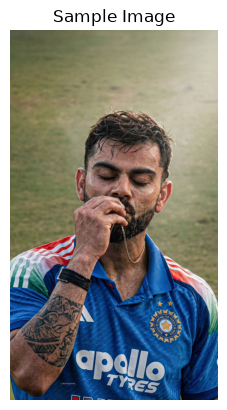

In [15]:
plt.imshow(image)
plt.title("Sample Image")
plt.axis("off")
plt.show()

In [16]:
print("Image Shape:", image_array.shape)
print("Data Type:", image_array.dtype)

Image Shape: (1600, 900, 3)
Data Type: uint8


2. Implement a simple 2D convolution operation in Python using NumPy: given a 5x5 grayscale image array and a 3x3 filter, compute the output feature map without using any deep learning libraries.<br><br><em><strong>Hint:</strong> Use nested loops to slide the filter over the image and sum the element-wise products.</em>

In [17]:
import numpy as np

In [18]:
image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 0]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

In [19]:
output_rows = image.shape[0] - kernel.shape[0] + 1
output_cols = image.shape[1] - kernel.shape[1] + 1

In [20]:
feature_map = np.zeros((output_rows, output_cols))

In [23]:
for i in range(output_rows):
    for j in range(output_cols):
        region = image[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(region * kernel)

In [24]:
print("Input Image:")
print(image)

print("\nKernel:")
print(kernel)

print("\nOutput Feature Map:")
print(feature_map)

Input Image:
[[1 2 3 0 1]
 [4 5 6 1 2]
 [7 8 9 2 3]
 [1 2 3 4 5]
 [6 7 8 9 0]]

Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Feature Map:
[[-6. 12. 12.]
 [-6.  8.  8.]
 [-6.  2. 12.]]


3. Draw the architecture diagram of a basic CNN (on paper or using a tool like draw.io) showing input layer, one convolutional layer, one pooling layer, and an output layer. Label each part and briefly describe its function in 1-2 lines.

| Layer | Function |
|--------|----------|
| **Input Layer** | Receives the input image as pixel values and passes it to the CNN for further processing. |
| **Convolution Layer** | Applies filters (kernels) to extract important features such as edges, textures, and shapes, generating feature maps. |
| **Pooling Layer** | Reduces the dimensions of the feature maps while preserving the most important information, making the model more efficient and reducing overfitting. |
| **Output Layer** | Produces the final prediction by classifying the extracted features into one of the target classes. |

4. Write a function in Python that takes an image array and returns a new array where each pixel is replaced by the maximum value in its 2x2 local neighborhood (simulate max pooling).<br><br><em><strong>Constraint:</strong> Do not use any deep learning libraries like TensorFlow or PyTorch for this task.</em>

In [26]:
def max_pooling(image):
    rows, cols = image.shape
    output = np.zeros((rows // 2, cols // 2), dtype=image.dtype)

    for i in range(0, rows, 2):
        for j in range(0, cols, 2):
            window = image[i:i+2, j:j+2]
            output[i // 2, j // 2] = np.max(window)

    return output

In [27]:
image = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 3],
    [4, 9, 5, 6]
])


In [28]:
pooled_image = max_pooling(image)

In [29]:
print("Original Image:")
print(image)

print("\nPooled Image:")
print(pooled_image)

Original Image:
[[1 3 2 4]
 [5 6 1 2]
 [7 2 8 3]
 [4 9 5 6]]

Pooled Image:
[[6 4]
 [9 8]]


5. Explain with a real-world example from Instagram or Zomato how translation invariance in CNNs is useful. Write 2-3 sentences connecting it to how these apps recognize faces or food items even if they appear in different positions in the image

**Example: Instagram**

Translation invariance allows a CNN to recognize the same object even if it appears in different positions within an image. For example, Instagram can detect and recognize a person's face whether it is in the center, corner, or side of a photo. This helps features like face recognition and photo tagging work accurately regardless of where the face is located.